# Workshop 1 - Exploratory Data Analysis
## `flwrlabs/shakespeare`: predicting the next character

**Course:** Machine Learning, Universidad Distrital
**Dataset:** [flwrlabs/shakespeare](https://huggingface.co/datasets/flwrlabs/shakespeare), the
Shakespeare part of the [LEAF](https://arxiv.org/abs/1812.01097) benchmark, built from
*The Complete Works of William Shakespeare* (Project Gutenberg). License: BSD-2-Clause.

### The task

Given an 80-character window `x` of dialogue, predict the single character `y` that comes next.
This is **multiclass classification**: exactly one of 79 classes is correct for each row.

### What this notebook covers

Data understanding only. Feature extraction, baseline models and training are out of scope
(see `README.md`). The goal is to decide two things with evidence: **which cleaning rules to
apply**, and **how to split the data**.

### About sampling

All statistics and figures use the **full dataset** (4,226,158 rows) - nothing is sampled. Where
a cell prints a few example rows, those are illustrations, not statistics.

---
## 0. Setup

In [1]:
"""Imports, project path and seed."""

import json
import sys
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# This notebook lives in notebooks/, so add the project folder to the path.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src import dataset as ds
from src.config import FIGURES_DIR, SEED, WINDOW_SIZE, set_seeds

set_seeds(SEED)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
print(f"project folder: {PROJECT_ROOT.name}")
print(f"seed: {SEED}")

project folder: NOTEBOOK
seed: 42


In [2]:
"""Three small helpers used below."""

def save_fig(fig, filename):
    """Save a figure into reports/figures/."""
    fig.savefig(FIGURES_DIR / filename, dpi=150, bbox_inches="tight")
    print(f"saved -> reports/figures/{filename}")


def show_char(char):
    """Make a character readable in a plot label (a space would be invisible)."""
    return {" ": "_", "\n": "\\n"}.get(char, char)


def entropy(counts):
    """Entropy in bits: how unpredictable something is.

    0 bits means always the same value; more bits means harder to guess.
    """
    p = counts / counts.sum()
    return float(-(p * np.log2(p)).sum())

In [3]:
"""Load the data. One DataFrame is used for the whole notebook."""

df = ds.load_raw()
print(f"rows: {len(df):,}")
df.head(3)

rows: 4,226,158


,character_id,x,y
0,THE_TRAGEDY_OF_TITUS_ANDRONICUS_A_ROMAN,"You sad Andronici, have done with woes; Give s...",a
1,THE_TRAGEDY_OF_TITUS_ANDRONICUS_A_ROMAN,"ou sad Andronici, have done with woes; Give se...",t
2,THE_TRAGEDY_OF_TITUS_ANDRONICUS_A_ROMAN,"u sad Andronici, have done with woes; Give sen...",


---
## 1. Overview

What the columns are, how big the data is, and what a row looks like.

In [4]:
print("SHAPE")
print(f"  rows   : {len(df):,}")
print(f"  columns: {len(df.columns)}")

print("\nDATA TYPES")
print(df.dtypes.to_string())

print(f"\nMEMORY: {df.memory_usage(deep=True).sum() / 2**20:,.1f} MiB")

SHAPE
  rows   : 4,226,158
  columns: 3

DATA TYPES
character_id    str
x               str
y               str

MEMORY: 560.6 MiB


In [5]:
"""Three consecutive rows, printed in full (an example, not a statistic)."""

for i in range(3):
    row = df.iloc[i]
    print(f"row {i}")
    print(f"  character_id : {row['character_id']}")
    print(f"  x ({len(row['x'])} chars): {row['x']!r}")
    print(f"  y            : {row['y']!r}")

row 0
  character_id : THE_TRAGEDY_OF_TITUS_ANDRONICUS_A_ROMAN
  x (80 chars): 'You sad Andronici, have done with woes; Give sentence on the execrable wretch Th'
  y            : 'a'
row 1
  character_id : THE_TRAGEDY_OF_TITUS_ANDRONICUS_A_ROMAN
  x (80 chars): 'ou sad Andronici, have done with woes; Give sentence on the execrable wretch Tha'
  y            : 't'
row 2
  character_id : THE_TRAGEDY_OF_TITUS_ANDRONICUS_A_ROMAN
  x (80 chars): 'u sad Andronici, have done with woes; Give sentence on the execrable wretch That'
  y            : ' '


### Findings - 1. Overview

- The dataset has **4,226,158 rows and 3 text columns**: `character_id` (who is speaking, i.e. a
  play + role), `x` (80 characters of context) and `y` (the next character).
- It takes about **561 MiB** in memory.
- The three example rows already show the key pattern: each `x` is the previous `x` moved one
  character to the left, with the previous `y` added at the end. Section 7 checks this on the
  whole dataset.
- Since `x` always has 80 characters and `y` always has 1, this is a **fixed-size multiclass
  classification** problem. No variable-length handling is needed.

---
## 2. Target distribution (`y`)

How often each class appears decides what a "good" accuracy even means, so this comes first.

In [6]:
class_counts = df["y"].value_counts()

target_entropy = entropy(class_counts)
uniform_entropy = float(np.log2(len(class_counts)))
top_char, top_count = class_counts.index[0], class_counts.iloc[0]

print(f"number of classes    : {len(class_counts)}")
print(f"most frequent class  : {top_char!r} -> {top_count:,} rows "
      f"({top_count / len(df):.4%})")
print(f"least frequent       : {class_counts.tail(2).to_dict()}")
print(f"imbalance ratio      : {top_count / class_counts.min():,.0f}x")
print(f"entropy H(y)         : {target_entropy:.4f} bits")
print(f"if classes were equal: {uniform_entropy:.4f} bits")
print(f"effective classes    : 2^H = {2 ** target_entropy:.1f}  (not 79)")
print(f"always predict {top_char!r}   : {top_count / len(df):.4%} accuracy "
      "<- the score any model must beat")

number of classes    : 79
most frequent class  : ' ' -> 791,902 rows (18.7381%)
least frequent       : {'0': 1, '9': 1}
imbalance ratio      : 791,902x
entropy H(y)         : 4.5002 bits
if classes were equal: 6.3038 bits
effective classes    : 2^H = 22.6  (not 79)
always predict ' '   : 18.7381% accuracy <- the score any model must beat


saved -> reports/figures/02_target_distribution.png


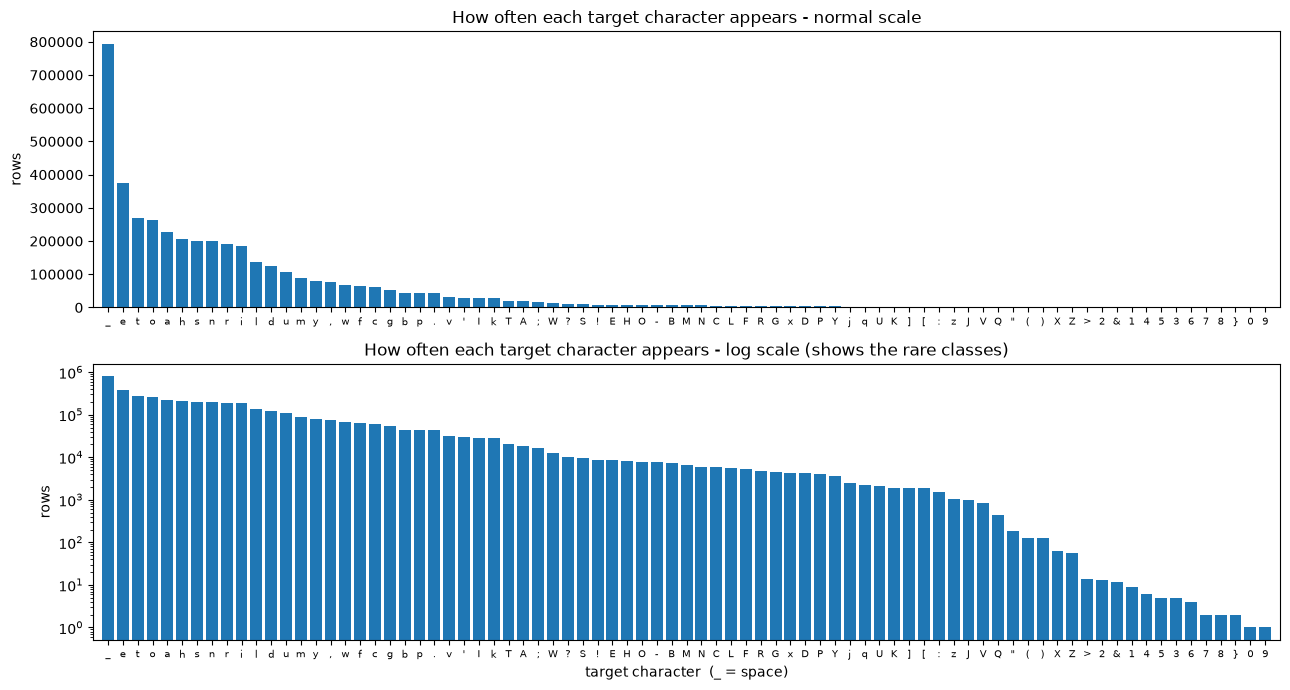

In [7]:
"""Class counts, on a normal and a log scale.

The log scale is the only way to see the rare classes at all.
"""

labels = [show_char(c) for c in class_counts.index]
positions = np.arange(len(class_counts))

fig, axes = plt.subplots(2, 1, figsize=(13, 7))
for ax, scale, subtitle in [
    (axes[0], "linear", "normal scale"),
    (axes[1], "log", "log scale (shows the rare classes)"),
]:
    ax.bar(positions, class_counts.values)
    ax.set_yscale(scale)
    ax.set_title(f"How often each target character appears - {subtitle}")
    ax.set_ylabel("rows")
    ax.set_xticks(positions)
    ax.set_xticklabels(labels, fontsize=7)
    ax.set_xlim(-1, len(class_counts))

axes[1].set_xlabel("target character  (_ = space)")
fig.tight_layout()
save_fig(fig, "02_target_distribution.png")
plt.show()

In [8]:
"""The 10 most and 10 least frequent classes."""

print("TOP 10")
print((class_counts.head(10) / len(df)).to_frame("share").join(
    class_counts.head(10).to_frame("count")).to_string())

print("\nBOTTOM 10")
print((class_counts.tail(10) / len(df)).to_frame("share").join(
    class_counts.tail(10).to_frame("count")).to_string())

TOP 10
      share   count
y                  
   0.187381  791902
e  0.088741  375033
t  0.063947  270251
o  0.062035  262170
a  0.053746  227141
h  0.048455  204779
s  0.047482  200666
n  0.047254  199703
r  0.045579  192624
i  0.043787  185052

BOTTOM 10
          share  count
y                     
1  2.129594e-06      9
4  1.419729e-06      6
5  1.183108e-06      5
3  1.183108e-06      5
6  9.464861e-07      4
7  4.732431e-07      2
8  4.732431e-07      2
}  4.732431e-07      2
0  2.366215e-07      1
9  2.366215e-07      1


### Findings - 2. Target distribution

- `y` has **79 classes**, and they are very unbalanced. The **space character alone is 791,902
  rows (18.74%)**, and the top 10 classes (space, `e`, `t`, `o`, `a`, `h`, `s`, `n`, `r`, `i`)
  cover about **two thirds** of the data.
- The rarest classes (`0` and `9`) appear **once each**, so the **imbalance ratio is 791,902:1**.
  Ten classes appear fewer than 10 times in 4.23 million rows.
- **H(y) = 4.5002 bits**, versus 6.3038 bits if all 79 classes were equally likely. In practice
  there are about **22.6 effective classes**, not 79.
- **A model that always predicts a space gets 18.74% accuracy** without learning anything.

**Why accuracy on its own is not enough here.** With this imbalance, accuracy is decided almost
entirely by the few frequent classes. A model can score ~19% having learned nothing, and it can
even *improve* its accuracy by ignoring every rare class. Accuracy also cannot tell apart a model
that handles 15 classes from one that handles 60, because the extra classes hold almost no rows.
So the modelling stage should also report **macro F1** (treats every class equally, so it shows
when the rare classes are ignored), **top-k accuracy** (several next characters are often
reasonable), **per-class recall** for the rare classes, and **cross-entropy**, which can be
compared directly with the 4.5002 bits above.

---
## 3. Characters (`character_id`)

Each `character_id` is one role in one play. How the rows are spread across them decides how the
data can be split.

In [9]:
per_character = df["character_id"].value_counts()

# How few characters make up half of the data?
running_total = per_character.cumsum() / len(df)
n_for_half = int((running_total < 0.50).sum() + 1)
n_for_eighty = int((running_total < 0.80).sum() + 1)

print(f"distinct characters  : {len(per_character):,}")
print(f"samples per character:")
print(per_character.describe().to_string())
print(f"\ncharacters with < 100 rows : {(per_character < 100).sum():,}")
print(f"characters holding 50% rows: {n_for_half} "
      f"({n_for_half / len(per_character):.1%})")
print(f"characters holding 80% rows: {n_for_eighty} "
      f"({n_for_eighty / len(per_character):.1%})")

print("\nTOP 10 CHARACTERS")
print(per_character.head(10).to_string())

distinct characters  : 1,129
samples per character:
count     1129.000000
mean      3743.275465
std       6215.008682
min          3.000000
25%        316.000000
50%       1163.000000
75%       4436.000000
max      66903.000000

characters with < 100 rows : 114
characters holding 50% rows: 113 (10.0%)
characters holding 80% rows: 291 (25.8%)

TOP 10 CHARACTERS
character_id
THE_TRAGEDY_OF_HAMLET__PRINCE_OF_DENMARK_HAM      66903
THE_TRAGEDY_OF_OTHELLO__MOOR_OF_VENICE_IAGO       45213
THE_LIFE_OF_KING_HENRY_THE_FIFTH_KING_HENRY       40758
MEASURE_FOR_MEASURE_DUKE                          36089
THE_LIFE_OF_TIMON_OF_ATHENS_TIMON                 35596
THE_TRAGEDY_OF_OTHELLO__MOOR_OF_VENICE_OTHELLO    34021
THE_TRAGEDY_OF_ANTONY_AND_CLEOPATRA_ANTONY        33521
KING_RICHARD_THE_SECOND_KING_RICHARD              32767
THE_TRAGEDY_OF_TITUS_ANDRONICUS_TITUS             31055
THE_TRAGEDY_OF_KING_LEAR_LEAR                     30900


saved -> reports/figures/03_rows_per_character.png


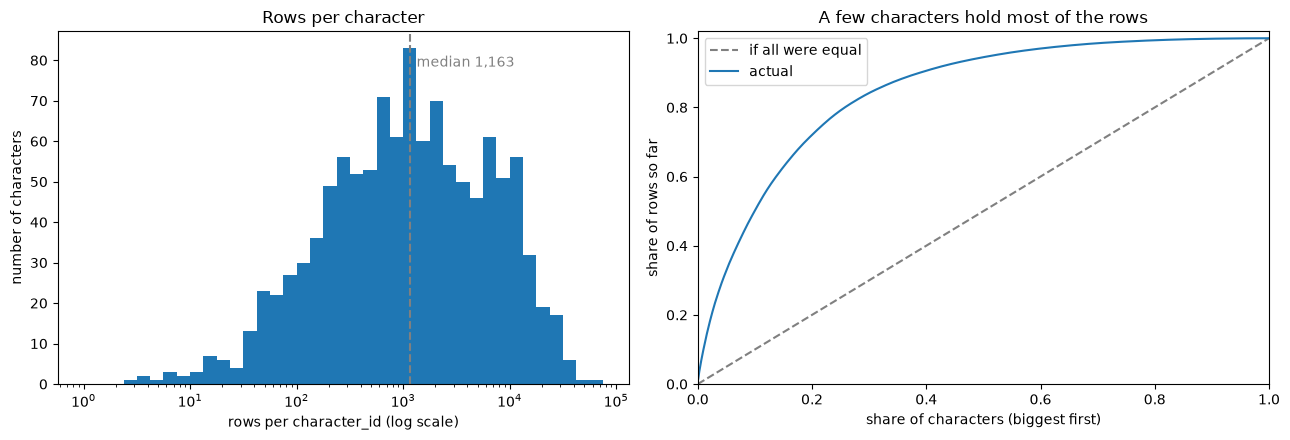

In [10]:
"""How character sizes are spread, and how concentrated the data is."""

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
# Sizes span four orders of magnitude, so the bins are spaced on a log scale.
bins = np.logspace(0, np.log10(per_character.max()) + 0.05, 40)
ax.hist(per_character, bins=bins)
ax.set_xscale("log")
ax.axvline(per_character.median(), color="gray", linestyle="--")
ax.set_title("Rows per character")
ax.set_xlabel("rows per character_id (log scale)")
ax.set_ylabel("number of characters")
ax.text(per_character.median() * 1.15, ax.get_ylim()[1] * 0.9,
        f"median {per_character.median():,.0f}", color="gray")

ax = axes[1]
x_axis = np.arange(1, len(per_character) + 1) / len(per_character)
ax.plot([0, 1], [0, 1], color="gray", linestyle="--", label="if all were equal")
ax.plot(x_axis, running_total.values, label="actual")
ax.set_title("A few characters hold most of the rows")
ax.set_xlabel("share of characters (biggest first)")
ax.set_ylabel("share of rows so far")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)
ax.legend()

fig.tight_layout()
save_fig(fig, "03_rows_per_character.png")
plt.show()

In [11]:
"""Get the play name out of character_id.

character_id looks like <PLAY>_<ROLE>, but both parts contain underscores, so we
cannot just split on "_". Idea: a play name is shared by many roles, a role name
is not. So for each id we take the longest prefix that at least MIN_ROLES other
ids also start with.
"""

MIN_ROLES = 10

# Count how many character ids start with each possible prefix.
prefix_counts = Counter()
for name in per_character.index:
    parts = name.split("_")
    for i in range(1, len(parts)):
        prefix_counts["_".join(parts[:i])] += 1


def get_play(name, min_roles=MIN_ROLES):
    """Longest prefix of `name` shared by at least `min_roles` character ids."""
    parts = name.split("_")
    best = name
    for i in range(1, len(parts)):
        prefix = "_".join(parts[:i])
        if prefix_counts[prefix] >= min_roles:
            best = prefix
    return best


# Is the threshold trustworthy? Check that the answer does not keep changing.
print("how many plays we get for different thresholds:")
for threshold in [2, 3, 5, 8, 10, 12, 15, 20]:
    n_plays = len({get_play(name, threshold) for name in per_character.index})
    mark = "  <- used" if threshold == MIN_ROLES else ""
    print(f"  at least {threshold:>2} roles -> {n_plays:>3} plays{mark}")

play = df["character_id"].map(get_play)
rows_per_play = play.value_counts()
print(f"\nplays found: {len(rows_per_play)}")

how many plays we get for different thresholds:
  at least  2 roles ->  83 plays
  at least  3 roles ->  57 plays
  at least  5 roles ->  42 plays
  at least  8 roles ->  38 plays
  at least 10 roles ->  36 plays  <- used
  at least 12 roles ->  36 plays
  at least 15 roles ->  36 plays
  at least 20 roles -> 105 plays



plays found: 36


saved -> reports/figures/04_rows_per_play.png


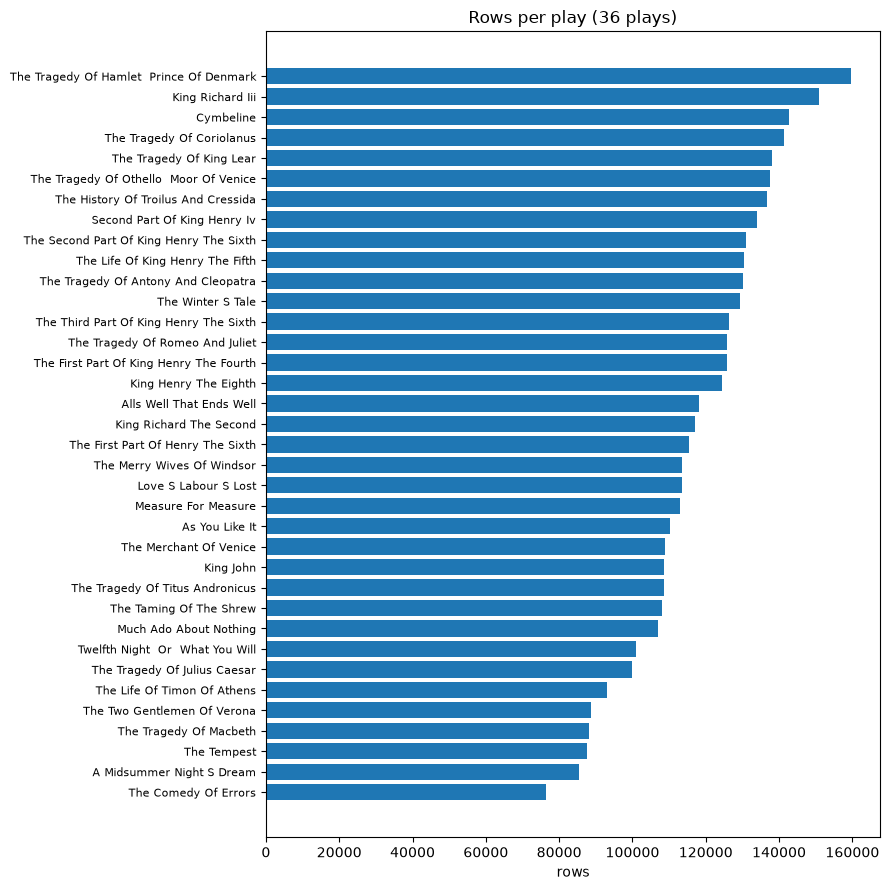

In [12]:
"""Rows per play."""

fig, ax = plt.subplots(figsize=(9, 9))
ordered = rows_per_play.sort_values()
ax.barh([name.replace("_", " ").title() for name in ordered.index], ordered.values)
ax.set_xlabel("rows")
ax.set_title(f"Rows per play ({len(ordered)} plays)")
ax.tick_params(axis="y", labelsize=8)
fig.tight_layout()
save_fig(fig, "04_rows_per_play.png")
plt.show()

### Findings - 3. Characters

- There are **1,129 characters**, and their sizes are extremely uneven: from **3 rows** to
  **66,903 rows** (`THE_TRAGEDY_OF_HAMLET__PRINCE_OF_DENMARK_HAM`), with a **median of 1,163** and
  a **mean of 3,743**. A mean much higher than the median means a long tail.
- The data is very concentrated: **113 characters (10%) hold half of all rows**, and 291 (26%)
  hold 80%. At the other end, **114 characters have fewer than 100 rows each**.
- **What this means for splitting:** if we keep each character entirely inside one split, we
  cannot get exactly 70/15/15 of the rows, because the groups are so different in size. The real
  result is 70.9 / 13.8 / 15.3 (Section 8).

**About the play heuristic and its limits.** `character_id` joins the play and the role with an
underscore, and both parts contain underscores, so there is no way to split it reliably. The rule
used here (longest prefix shared by at least 10 roles) finds **36 plays**, which matches the
number of works in the LEAF Shakespeare data, and the answer **does not change for any threshold
between 10 and 20**. Its limits:

- With a lower threshold it splits too much. At 5 it gives 42 groups, separating `CYMBELINE` from
  a made-up `CYMBELINE_FIRST` caused by generic roles like `FIRST_LORD`.
- A play with fewer than 10 speaking roles would be attached to a shorter prefix or not detected.
- It is guessed from the text of the ids, not taken from a real list of plays. So it is used
  **only to describe the data**. The split in `src/dataset.py` groups by `character_id`, which is
  an exact column, never by the guessed play.

---
## 4. What the `x` windows are made of

In [13]:
print("x lengths:", df["x"].str.len().value_counts().to_dict())
print("y lengths:", df["y"].str.len().value_counts().to_dict())

# Count every character in x and in y (over all 4.2 M rows).
counts_x = pd.Series(ds.character_counts(df["x"])).sort_values(ascending=False)
counts_y = pd.Series(ds.character_counts(df["y"])).sort_values(ascending=False)

print(f"\ndifferent characters in x: {len(counts_x)}")
print(f"different characters in y: {len(counts_y)}")
print(f"in x but never in y: {sorted(set(counts_x.index) - set(counts_y.index))}")
print(f"in y but never in x: {sorted(set(counts_y.index) - set(counts_x.index))}")
print(f"same alphabet: {set(counts_x.index) == set(counts_y.index)}")

x lengths: {80: 4226158}
y lengths: {1: 4226158}



different characters in x: 79
different characters in y: 79
in x but never in y: []
in y but never in x: []
same alphabet: True


In [14]:
"""What kinds of characters appear in x."""

total = counts_x.sum()
groups = {
    "lowercase": sum(counts_x[c] for c in counts_x.index if c.islower()),
    "space": counts_x.get(" ", 0),
    "punctuation": sum(counts_x[c] for c in counts_x.index
                       if not c.isalnum() and c != " "),
    "uppercase": sum(counts_x[c] for c in counts_x.index if c.isupper()),
    "digits": sum(counts_x[c] for c in counts_x.index if c.isdigit()),
}

print(f"total characters in x: {total:,}\n")
for name, count in groups.items():
    print(f"  {name:<13}{count:>14,}{count / total:>10.4%}")

non_ascii = sum(counts_x[c] for c in counts_x.index if ord(c) > 127)
control = sum(counts_x[c] for c in counts_x.index if ord(c) < 32 or ord(c) == 127)
print(f"\n  non-ASCII characters: {non_ascii:,}")
print(f"  control characters  : {control:,}")

total characters in x: 338,092,640

  lowercase       244,887,119  72.4320%
  space            63,334,205  18.7328%
  punctuation      15,689,870   4.6407%
  uppercase        14,177,811   4.1935%
  digits                3,635   0.0011%

  non-ASCII characters: 0
  control characters  : 0


saved -> reports/figures/05_character_composition.png


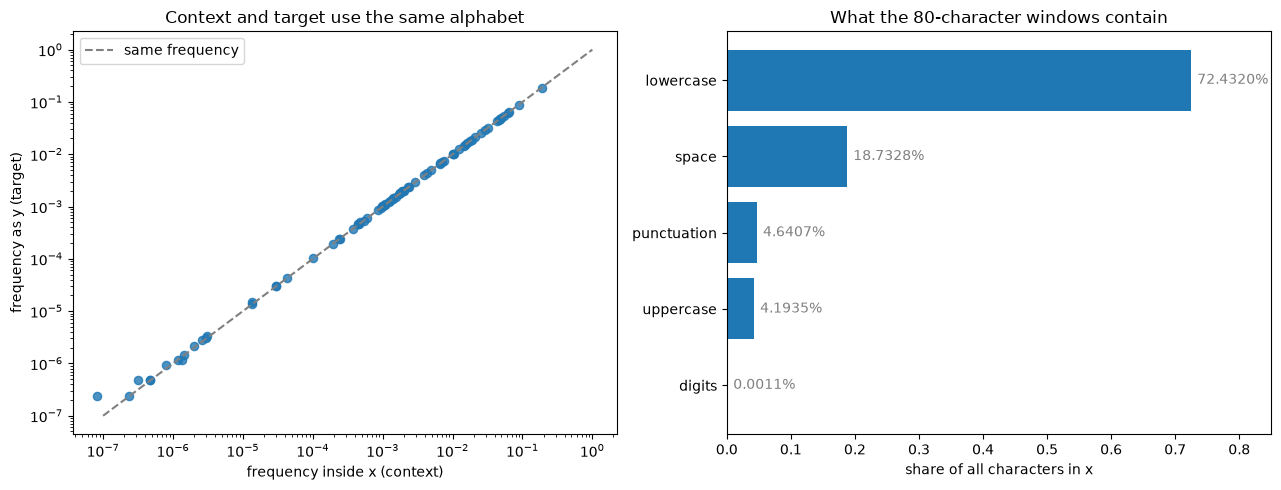

In [15]:
"""Is a character as common inside x as it is as a target?"""

share_x = counts_x / counts_x.sum()
share_y = counts_y / len(df)
compare = pd.DataFrame({"in_x": share_x, "in_y": share_y}).dropna()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.plot([1e-7, 1], [1e-7, 1], color="gray", linestyle="--", label="same frequency")
ax.scatter(compare["in_x"], compare["in_y"], s=35, alpha=0.8)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("frequency inside x (context)")
ax.set_ylabel("frequency as y (target)")
ax.set_title("Context and target use the same alphabet")
ax.legend()

ax = axes[1]
names = list(groups)[::-1]
values = [groups[n] / total for n in names]
ax.barh(names, values)
ax.set_xlabel("share of all characters in x")
ax.set_title("What the 80-character windows contain")
ax.set_xlim(0, 0.85)
for i, value in enumerate(values):
    ax.text(value + 0.01, i, f"{value:.4%}", va="center", color="gray")

fig.tight_layout()
save_fig(fig, "05_character_composition.png")
plt.show()

### Findings - 4. What the `x` windows are made of

- **Every one of the 4,226,158 windows has exactly 80 characters**, and every target exactly 1.
  There is no length variation to deal with.
- **`x` and `y` use exactly the same alphabet**: 79 characters each, with nothing in one that is
  missing from the other. So a single character-to-number mapping works for both
  (`data/vocab.json`).
- Of the 338,092,640 characters in `x`: **72.43% lowercase, 18.73% space, 4.64% punctuation,
  4.19% uppercase, 0.0011% digits**. The share of spaces inside `x` matches their 18.74% share as
  targets almost exactly, which is what we expect if the windows slide over the same text.
- There are **zero non-ASCII characters and zero control characters**. This is a cleaning decision
  backed by a measurement: Unicode NFC normalisation would change nothing here, so it is **not
  applied**.
- Digits are almost absent (0.0011%, about 3,700 characters in total). That is why digit classes
  like `0`, `8` and `9` sit at the very bottom of the target distribution, and why in Section 8
  some of them end up missing from the training split entirely.

---
## 5. Data quality

These checks run through `src.dataset.validate`, the same function the cleaning pipeline uses, so
the numbers here and in the pipeline cannot disagree.

In [16]:
report = ds.validate(df)

print("BASIC CHECKS")
print(f"  missing values           : {report['nulls']}")
print(f"  empty strings            : {report['empty_strings']}")
print(f"  rows with len(x) != 80   : {report['wrong_x_length']:,}")
print(f"  rows with len(y) != 1    : {report['wrong_y_length']:,}")
print(f"  rows with non-ASCII chars: {report['rows_with_non_ascii']:,}")
print(f"  rows with control chars  : {report['rows_with_control_chars']:,}")
print(f"  rows with repeated spaces: {report['rows_with_repeated_spaces']:,}")

print("\nDUPLICATES")
print(f"  different x windows      : {report['n_unique_x']:,}")
print(f"  different (x, y) pairs   : {report['n_unique_xy']:,}")
print(f"  exact duplicate rows     : {report['exact_duplicate_rows']:,} "
      f"({report['exact_duplicate_rows'] / len(df):.4%})")
print(f"  (x, y) used by >1 character: {report['pairs_under_several_characters']:,}")

print("\nCONTRADICTORY DATA")
print(f"  windows with more than one target: {report['conflicting_windows']:,}")
print(f"  rows involved                    : {report['conflicting_rows']:,} "
      f"({report['conflicting_rows'] / len(df):.6%})")

usable = ds.usable_rows(report)
print(f"\nUSABLE ROWS: {usable:,} / {len(df):,} ({usable / len(df):.4%})")

BASIC CHECKS
  missing values           : {'character_id': 0, 'x': 0, 'y': 0}
  empty strings            : {'character_id': 0, 'x': 0, 'y': 0}
  rows with len(x) != 80   : 0
  rows with len(y) != 1    : 0
  rows with non-ASCII chars: 0
  rows with control chars  : 0
  rows with repeated spaces: 0

DUPLICATES
  different x windows      : 4,224,322
  different (x, y) pairs   : 4,224,336
  exact duplicate rows     : 1,445 (0.0342%)
  (x, y) used by >1 character: 377

CONTRADICTORY DATA
  windows with more than one target: 12
  rows involved                    : 29 (0.000686%)

USABLE ROWS: 4,224,713 / 4,226,158 (99.9658%)


In [17]:
"""Look at the windows whose targets disagree."""

targets_per_window = df.groupby("x")["y"].nunique()
conflicting = targets_per_window[targets_per_window > 1].index

print(f"{len(conflicting)} windows have more than one target\n")
for window in conflicting[:4]:
    rows = df[df["x"] == window]
    print(f"  x = {window!r}")
    print(f"  y seen = {sorted(rows['y'].unique())}  "
          f"({rows['character_id'].nunique()} character(s))\n")

12 windows have more than one target



  x = ' hither, come hither. Here shall he see No enemy But winter and rough weather. I'
  y seen = ["'", 't']  (2 character(s))

  x = 'ION INCLUDES BY ANY SERVICE THAT CHARGES FOR DOWNLOAD TIME OR FOR MEMBERSHIP.>> '
  y seen = ['1', 'D', 'P', 'T']  (1 character(s))



  x = 'Lewis of France is sending over masquers To revel it with him and his new bride.'
  y seen = [' ', "'"]  (2 character(s))

  x = "humus end his miseries, Britain be fortunate and flourish in peace and plenty.' "
  y seen = ["'", 'T']  (2 character(s))



### Findings - 5. Data quality

**The data is already clean.** Every basic check returns zero:

| check | rows | share |
|---|---:|---:|
| missing values | 0 | 0% |
| empty strings | 0 | 0% |
| `len(x) != 80` | 0 | 0% |
| `len(y) != 1` | 0 | 0% |
| non-ASCII characters | 0 | 0% |
| control characters | 0 | 0% |
| repeated spaces in `x` | 0 | 0% |

- The **zero repeated spaces is itself a finding**: LEAF already collapsed them when it built the
  windows. There is no whitespace cleaning left to do, and writing that rule would do nothing.
- **Duplicates:** 4,224,322 different windows and 4,224,336 different `(x, y)` pairs out of
  4,226,158 rows. **1,445 rows (0.0342%) repeat an earlier `(character_id, x, y)` row.** Also
  **377 `(x, y)` pairs are spoken by more than one character**, usually short common phrases.
- **Contradictory data:** **12 windows have more than one target**, covering **29 rows
  (0.000686%)**. For these, the exact same 80 characters are followed by different characters, so
  **no model that only reads `x` can get all of them right**. This puts a ceiling on accuracy, but
  at 7 rows per million it is not a practical problem.
- **99.9658% of rows (4,224,713) are usable.** Only the 1,445 duplicates are removed.

**The cleaning rules these numbers justify** - and the ones they rule out:

| rule | applied? | rows | why |
|---|---|---:|---|
| drop malformed rows | yes (removes 0) | 0 | no row breaks the length rule, but the check stays |
| drop exact duplicate rows | **yes** | 1,445 | no extra information, and they stay inside one split anyway |
| Unicode NFC normalisation | **no** | 0 | no non-ASCII characters, so it would change nothing |
| collapse repeated spaces | **no** | 0 | already done upstream; the rule would never fire |
| lowercase / remove punctuation | **no** | - | case, punctuation and space **are target classes**; this would destroy the labels |
| drop contradictory rows | **no** | 29 | real ambiguity in the text, not an error; removing it would make the evaluation look better than it is |

---
## 6. How much does the context tell us?

Sections 2-4 describe each column on its own. This section measures the **relationship** between
the window and the target, which is what a model has to learn.

saved -> reports/figures/06_bigram_transitions.png


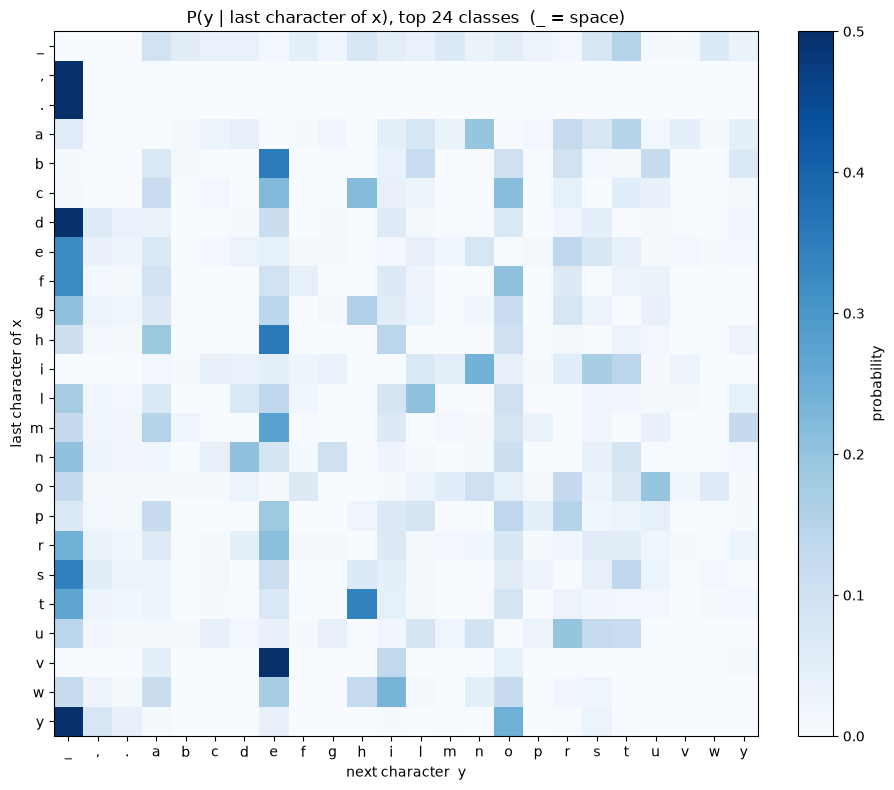

this grid covers 86.94% of all rows


In [18]:
"""Which character follows which: P(y | last character of x)."""

TOP = 24
frequent = class_counts.head(TOP).index.sort_values()

last_char = df["x"].str[-1]
mask = last_char.isin(frequent) & df["y"].isin(frequent)
transitions = pd.crosstab(last_char[mask], df["y"][mask], normalize="index")

fig, ax = plt.subplots(figsize=(9, 8))
image = ax.imshow(transitions.values, cmap="Blues", vmin=0, vmax=0.5)
ax.set_xticks(range(len(transitions.columns)))
ax.set_yticks(range(len(transitions.index)))
ax.set_xticklabels([show_char(c) for c in transitions.columns])
ax.set_yticklabels([show_char(c) for c in transitions.index])
ax.set_xlabel("next character  y")
ax.set_ylabel("last character of x")
ax.set_title(f"P(y | last character of x), top {TOP} classes  (_ = space)")
fig.colorbar(image, ax=ax, fraction=0.045, label="probability")
fig.tight_layout()
save_fig(fig, "06_bigram_transitions.png")
plt.show()

print(f"this grid covers {mask.mean():.2%} of all rows")

In [19]:
"""The strongest patterns, including ones too rare for the heatmap."""

def most_likely_next(character, k=3):
    """The k most likely next characters after `character`."""
    following = df.loc[df["x"].str[-1] == character, "y"]
    return (following.value_counts(normalize=True).head(k) * 100).round(1).to_dict()


for character in ["q", ".", ",", "v", "t", "y", " "]:
    print(f"  after {character!r:<4} -> {most_likely_next(character)}  (%)")

  after 'q'  -> {'u': 100.0}  (%)


  after '.'  -> {' ': 97.9, "'": 1.0, ']': 0.6}  (%)


  after ','  -> {' ': 99.7, "'": 0.2, '-': 0.0}  (%)


  after 'v'  -> {'e': 74.6, 'i': 12.9, 'a': 4.6}  (%)


  after 't'  -> {'h': 33.3, ' ': 26.3, 'o': 8.4}  (%)


  after 'y'  -> {' ': 51.5, 'o': 23.5, ',': 7.8}  (%)


  after ' '  -> {'t': 12.0, 'a': 7.5, 's': 6.2}  (%)


In [20]:
"""How much uncertainty is left after seeing the last k characters.

There is a standard identity for this: H(y | context) = H(context, y) - H(context).
So we only need to count how often each pair and each context appear, and reuse the
`entropy` helper from the setup.
"""

def conditional_entropy(context, target):
    """H(target | context) in bits."""
    pair_counts = pd.DataFrame({"a": context, "b": target}).value_counts()
    return entropy(pair_counts) - entropy(context.value_counts())


MAX_K = 5
entropies = {0: target_entropy}   # k = 0 means no context at all
n_contexts = {0: 1}

for k in range(1, MAX_K + 1):
    context = df["x"].str[-k:]          # the last k characters of each window
    entropies[k] = conditional_entropy(context, df["y"])
    n_contexts[k] = context.nunique()

table = pd.DataFrame({
    "H(y | last k)": pd.Series(entropies).round(4),
    "information gained": (target_entropy - pd.Series(entropies)).round(4),
    "uncertainty left": (pd.Series(entropies) / target_entropy).round(3),
    "different contexts": pd.Series(n_contexts),
})
table.index.name = "k"
print(table.to_string())

   H(y | last k)  information gained  uncertainty left  different contexts
k                                                                         
0         4.5002              0.0000             1.000                   1
1         3.5288              0.9714             0.784                  79
2         2.8207              1.6795             0.627                1813
3         2.2994              2.2008             0.511               15527
4         1.9516              2.5486             0.434               74972
5         1.6903              2.8099             0.376              244677


saved -> reports/figures/07_conditional_entropy.png


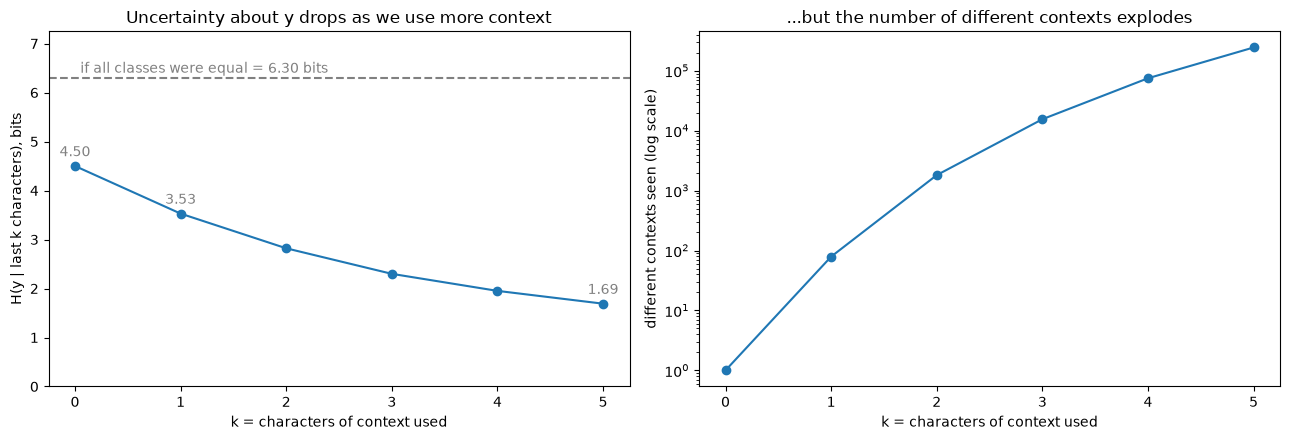

In [21]:
"""Context helps - but the number of contexts grows very fast."""

ks = list(entropies)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
ax.axhline(uniform_entropy, color="gray", linestyle="--")
ax.text(0.05, uniform_entropy + 0.1,
        f"if all classes were equal = {uniform_entropy:.2f} bits", color="gray")
ax.plot(ks, list(entropies.values()), marker="o")
for k in [0, 1, MAX_K]:
    ax.text(k, entropies[k] + 0.2, f"{entropies[k]:.2f}", ha="center", color="gray")
ax.set_title("Uncertainty about y drops as we use more context")
ax.set_xlabel("k = characters of context used")
ax.set_ylabel("H(y | last k characters), bits")
ax.set_ylim(0, uniform_entropy * 1.15)
ax.set_xticks(ks)

ax = axes[1]
ax.plot(ks, list(n_contexts.values()), marker="o")
ax.set_yscale("log")
ax.set_title("...but the number of different contexts explodes")
ax.set_xlabel("k = characters of context used")
ax.set_ylabel("different contexts seen (log scale)")
ax.set_xticks(ks)

fig.tight_layout()
save_fig(fig, "07_conditional_entropy.png")
plt.show()

### Findings - 6. How much does the context tell us?

- The heatmap shows **real patterns, not noise**, and they are the ones English spelling predicts.
  Punctuation is almost deterministic: after `,` a space follows **99.7%** of the time, after `.`
  it is **97.9%**. Letters are strong but not certain: `v` is followed by `e` **74.6%** of the
  time, `t` by `h` **33.3%**, `y` by a space **51.5%**. A space is the least useful thing to see:
  after it, the most likely next character is `t` with only **12.0%**.
- The strongest pattern in the whole dataset is not even in the heatmap, because `q` is too rare
  to be in the top 24: **`q` is followed by `u` in all 2,272 cases - exactly 100%**. Useful
  patterns live in the rare classes too, which is a reason not to throw them away.
- **Uncertainty drops as we use more context:**

| k | H(y \| last k) | information gained | uncertainty left | different contexts |
|--:|--:|--:|--:|--:|
| 0 | 4.5002 | - | 100.0% | 1 |
| 1 | 3.5288 | 0.9714 | 78.4% | 79 |
| 2 | 2.8207 | 1.6795 | 62.7% | 1,813 |
| 3 | 2.2994 | 2.2008 | 51.1% | 15,527 |
| 4 | 1.9516 | 2.5486 | 43.4% | 74,972 |
| 5 | 1.6903 | 2.8099 | 37.6% | 244,677 |

- **One character of context removes 21.6% of the uncertainty; five characters remove 62.4%.** So
  the task is clearly learnable, but far from easy: even with 5 characters, **1.69 bits of
  uncertainty remain**, and the full window is 80 characters long.
- **The cost matters too.** The number of different contexts grows from 79 to 244,677 between
  k = 1 and k = 5, roughly 3x per extra character. A model that just memorises a table of contexts
  will run out of training examples long before it runs out of window. That is the argument for a
  model that *learns* a representation instead of counting, which belongs to the next stage.
- The gain per extra character is already shrinking (0.97, 0.71, 0.52, 0.35, 0.26 bits), so most
  of the easy signal is in the **last ~5 characters**.

---
## 7. Overlapping rows and data leakage

The dataset card warns about how you split this data. This section shows exactly why.

In [22]:
"""Six rows in a row, so the pattern is visible."""

print(f"character_id: {df.iloc[0]['character_id']}\n")
for i in range(6):
    print(f"  row {i}: x={df.iloc[i]['x']!r}  y={df.iloc[i]['y']!r}")

print("\nChecking: is x of the next row equal to x[1:] + y ?")
for i in range(3):
    rebuilt = df.iloc[i]["x"][1:] + df.iloc[i]["y"]
    print(f"  row {i} -> row {i + 1}: {rebuilt == df.iloc[i + 1]['x']}")

character_id: THE_TRAGEDY_OF_TITUS_ANDRONICUS_A_ROMAN

  row 0: x='You sad Andronici, have done with woes; Give sentence on the execrable wretch Th'  y='a'
  row 1: x='ou sad Andronici, have done with woes; Give sentence on the execrable wretch Tha'  y='t'
  row 2: x='u sad Andronici, have done with woes; Give sentence on the execrable wretch That'  y=' '
  row 3: x=' sad Andronici, have done with woes; Give sentence on the execrable wretch That '  y='h'
  row 4: x='sad Andronici, have done with woes; Give sentence on the execrable wretch That h'  y='a'
  row 5: x='ad Andronici, have done with woes; Give sentence on the execrable wretch That ha'  y='t'

Checking: is x of the next row equal to x[1:] + y ?
  row 0 -> row 1: True
  row 1 -> row 2: True
  row 2 -> row 3: True


In [23]:
"""Now check that on every pair of consecutive rows in the dataset."""

same_character = df["character_id"].shift(-1) == df["character_id"]
follows_pattern = df["x"].shift(-1) == df["x"].str[1:] + df["y"]

n_pairs = int(same_character.sum())
n_matching = int((same_character & follows_pattern).sum())

print(f"consecutive row pairs              : {len(df) - 1:,}")
print(f"  of those, same character         : {n_pairs:,}")
print(f"  where the next x is x[1:] + y    : {n_matching:,}")
print(f"  that is                          : {n_matching / n_pairs:.6%}")
print(f"  exceptions                       : {n_pairs - n_matching:,}")
print(f"\nSo two consecutive rows share {WINDOW_SIZE - 1} of their {WINDOW_SIZE} "
      f"characters = {(WINDOW_SIZE - 1) / WINDOW_SIZE:.2%}")

consecutive row pairs              : 4,226,157
  of those, same character         : 4,225,029
  where the next x is x[1:] + y    : 4,225,029
  that is                          : 100.000000%
  exceptions                       : 0

So two consecutive rows share 79 of their 80 characters = 98.75%


In [24]:
"""What would go wrong with a random split by row."""

TRAIN_SHARE = 0.70
p_neighbour_in_train = 1 - (1 - TRAIN_SHARE) ** 2

print("Imagine shuffling all rows and taking 70% for training.")
print(f"  each neighbour of a validation row lands in train with p = {TRAIN_SHARE}")
print(f"  P(at least one neighbour in train) = 1 - 0.30^2 = {p_neighbour_in_train:.1%}")
print(f"  that neighbour shares {(WINDOW_SIZE - 1) / WINDOW_SIZE:.1%} of its characters,")
print("  and its target IS the 80th character of the validation row's input.")
print("\n  => validation accuracy would measure memorising, not learning.")

print(f"\nNote: each window appears only "
      f"{len(df) / df['x'].nunique():.4f} times on average,")
print("so this is not a duplicates problem. The overlap itself is the problem.")

Imagine shuffling all rows and taking 70% for training.
  each neighbour of a validation row lands in train with p = 0.7
  P(at least one neighbour in train) = 1 - 0.30^2 = 91.0%
  that neighbour shares 98.8% of its characters,
  and its target IS the 80th character of the validation row's input.

  => validation accuracy would measure memorising, not learning.



Note: each window appears only 1.0004 times on average,
so this is not a duplicates problem. The overlap itself is the problem.


### Findings - 7. Overlapping rows and data leakage

- **The overlap is exact, not approximate.** Out of the **4,225,029** consecutive row pairs that
  belong to the same character, **4,225,029 follow the rule `x[i+1] == x[i][1:] + y[i]` - that is
  100.000000%, with no exceptions.** The other 1,128 pairs are exactly the points where one
  character ends and the next begins.
- So the rows are a **window sliding one character at a time**: **row `i` and row `i+1` share 79
  of their 80 characters (98.75%)**, and row `i`'s target is literally the last input character of
  row `i+1`.
- **Why a random split by row would be wrong.** With 70% of rows in training, a validation row has
  a **1 - 0.30² = 91.0% chance** that at least one of its neighbours is in training. That
  neighbour is 98.75% identical, and its answer is part of the validation row's own input. The
  model would not need to learn anything: looking up an almost identical row would be enough, and
  the validation score would be meaningless.
- This is **not** a duplicates problem: each window appears only 1.0004 times on average, so
  removing duplicates would not help. The problem is built into how the rows were made, so the
  **split has to be built differently too**.
- **Two ways to avoid it.** (a) Group by `character_id`, so overlapping rows cannot end up in
  different splits because they all belong to the same speaker. (b) Cut each character's text into
  blocks in order, leaving a gap of at least 79 rows between them. Section 8 says which one was
  chosen and why.

---
## 8. Summary and the decisions that follow

In [25]:
"""Compare this notebook against what the pipeline actually produced."""

splits = ds.read_splits_file()
vocab = ds.read_vocab()
prepare_report = json.loads(
    (PROJECT_ROOT / "data" / "processed" / "prepare_report.json").read_text("utf-8")
)

print("SPLIT (grouped by character_id)")
print(pd.DataFrame(splits["counts"]).T.to_string())

print(f"\nno character in two splits: {prepare_report['split_check']}")
gap = prepare_report["largest_class_share_gap"]
print(f"biggest class frequency gap between splits: "
      f"{gap['max_share_difference']:.4%} (class {gap['class']!r})")

print(f"\nVOCABULARY (built from train only): {vocab['size']} tokens")
for name in ["train", "val", "test"]:
    print(f"  {name:<6}{prepare_report['unknown_characters'][name]}")

missing = sorted(set(counts_y.index) - (set(vocab["stoi"]) - {vocab["unk_token"]}))
print(f"\nclasses that never appear in train: {missing}")

SPLIT (grouped by character_id)
       n_characters     n_rows  character_share  row_share
train         790.0  2997217.0         0.699734   0.709449
val           169.0   583098.0         0.149690   0.138021
test          170.0   644398.0         0.150576   0.152531

no character in two splits: {'pairwise_overlaps': {'train&val': 0, 'train&test': 0, 'val&test': 0}, 'disjoint': True}
biggest class frequency gap between splits: 0.1643% (class 't')

VOCABULARY (built from train only): 76 tokens
  train {'unknown_chars_in_x': [], 'unknown_char_occurrences_in_x': 0, 'rows_with_unknown_target': 0}
  val   {'unknown_chars_in_x': ['8', '9'], 'unknown_char_occurrences_in_x': 160, 'rows_with_unknown_target': 2}
  test  {'unknown_chars_in_x': ['0', '8', '>'], 'unknown_char_occurrences_in_x': 591, 'rows_with_unknown_target': 4}

classes that never appear in train: ['0', '8', '9', '>']


### Findings - 8. Summary

#### The main findings

1. **Size and shape.** 4,226,158 rows, 3 text columns, 1,129 characters across 36 plays. Every `x`
   has 80 characters, every `y` has 1.
2. **The rows overlap.** 100.000000% of the 4,225,029 consecutive same-character pairs follow
   `x[i+1] == x[i][1:] + y[i]`, with no exceptions. Neighbouring rows share 98.75% of their
   characters. This is the most important fact in the dataset.
3. **The target is very unbalanced.** 79 classes; space alone is 18.74%; the rarest appear once;
   imbalance ratio 791,902:1. H(y) = 4.5002 bits out of a possible 6.3038, so there are about 22.6
   effective classes.
4. **Always predicting a space gives 18.74% accuracy**, which is why accuracy alone is not a good
   headline metric.
5. **Characters are very uneven.** 113 of 1,129 (10%) hold half the rows; 114 have fewer than 100
   rows; sizes go from 3 to 66,903.
6. **The data is already clean.** Zero missing values, zero empty strings, zero wrong lengths,
   zero non-ASCII characters, zero control characters, zero repeated spaces. 99.9658% of rows are
   usable.
7. **Very few duplicates or contradictions.** 1,445 duplicate rows (0.0342%); 12 windows with more
   than one target, covering 29 rows (0.000686%).
8. **Context helps, but only so much.** One character of context removes 21.6% of the uncertainty,
   five remove 62.4% - while the number of different contexts grows from 79 to 244,677.

#### The preprocessing decisions

| # | Decision | Based on finding |
|---|---|---|
| 1 | **Do not lowercase, remove punctuation or collapse spaces.** | #3 - case, punctuation and space are target classes |
| 2 | **Do not apply Unicode NFC normalisation.** | #6 - no non-ASCII characters, so it changes nothing |
| 3 | **Remove the 1,445 duplicate rows, and nothing else.** | #7 - no extra information, and they stay inside one split |
| 4 | **Keep the 29 contradictory rows.** | #7 - real ambiguity; removing it would flatter the evaluation |
| 5 | **Never split rows randomly. Split by `character_id`.** | #2 - a random split leaks an almost identical row into training for 91% of validation rows |
| 6 | **Build the vocabulary from train only, with an `<UNK>` token.** | #3, #5 - rare classes can be missing from train entirely |
| 7 | **Report macro F1, top-k accuracy and per-class recall as well as accuracy.** | #3, #4 - accuracy alone is decided by the space class |

#### The split and what it costs

`src/dataset.py` splits **by `character_id`** using `GroupShuffleSplit` twice (`SEED = 42`),
70/15/15 **of characters**:

| split | characters | rows | share of rows |
|---|---:|---:|---:|
| train | 790 | 2,997,217 | 70.94% |
| val | 169 | 583,098 | 13.80% |
| test | 170 | 644,398 | 15.25% |

- **No character appears in two splits** - all three pairwise overlaps are 0 - so overlapping rows
  cannot cross between splits. The leak from finding #2 becomes impossible.
- **The row shares are not exactly 70/15/15** because characters differ so much in size
  (finding #5). The real shares are reported instead of forced.
- **The class distribution survives:** the biggest difference in class frequency between any two
  splits is only **0.1643 percentage points** (class `t`).
- **But grouping has a real cost.** The train vocabulary has **75 characters + `<UNK>` = 76
  tokens**, while the full data has 79. The characters `0`, `8`, `9` and `>` appear **only in
  val/test**, because each occurs in a handful of rows belonging to a few characters (finding #5,
  and digits are only 0.0011% of `x`). They become `<UNK>`: **2 rows in val and 4 in test have a
  target the model never saw**, plus 160 and 591 unknown characters inside `x`. That is about 1
  row per million - it will not change any overall score, but it must not be hidden when reporting
  per-class results.
- The other option - cutting each character's text into blocks with a 79-row gap - would keep all
  79 classes in training, but would only test on characters the model already saw. `README.md`
  explains why the character-grouped split was chosen instead.

#### Not covered here

Feature extraction, baseline models and training. See `README.md` > *Out of scope / Next steps*.